In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import shap

In [99]:
counts = pd.read_csv("TCGA_KIRC_counts.csv", index_col=0)
genes = pd.read_csv("TCGA_KIRC_gene_annotation.csv")
metadata = pd.read_csv("TCGA_KIRC_sample_metadata.csv")

In [100]:
metadata = metadata[metadata["sample_type"] != "Additional - New Primary"]
counts = counts[metadata["barcode"]]

In [101]:
mask = (counts >= 10).sum(axis=1) >=20
counts_filtered = counts.loc[mask]

print(f"Original counts: {counts.shape}")
print(f"Filtered counts: {counts_filtered.shape}")

Original counts: (60660, 613)
Filtered counts: (30260, 613)


In [102]:
X = counts_filtered.T
y = metadata["sample_type"]

print(X.shape)
print(y.shape)

(613, 30260)
(613,)


In [103]:
X_log = np.log2(X + 1) 

In [104]:
encoder = LabelEncoder()
y_encoder = encoder.fit_transform(y)
print(encoder.classes_)

['Primary Tumor' 'Solid Tissue Normal']


In [105]:
X_train, X_test, y_train, y_test= train_test_split(
    X_log,
    y,
    test_size = 0.3,
    stratify= y,
    random_state=42
)

In [106]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
lasso = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    cv=5,
    scoring="accuracy",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

/Users/mateopalmieri/miniconda3/envs/pec2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/mateopalmieri/miniconda3/envs/pec2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/mateopalmieri/miniconda3/envs/pec2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setti

In [11]:
lasso.fit(X_train_scaled, y_train)

/Users/mateopalmieri/miniconda3/envs/pec2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/mateopalmieri/miniconda3/envs/pec2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/mateopalmieri/miniconda3/envs/pec2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setti

In [107]:
coef = pd.Series(
    lasso.coef_[0],
    index=X_train.columns
)

selected_genes = coef[coef != 0]

print(f"Genes seleccionados {len(selected_genes)}")
selected_genes.sort_values(key=np.abs, ascending=False).head(20)

Genes seleccionados 95


ENSG00000258402.1     0.071667
ENSG00000124157.7     0.070431
ENSG00000258292.1     0.069331
ENSG00000263429.3     0.067091
ENSG00000257191.1     0.057140
ENSG00000223783.1     0.056895
ENSG00000259730.1     0.055112
ENSG00000164853.9     0.054285
ENSG00000254789.3     0.050470
ENSG00000250529.1     0.046888
ENSG00000285640.1     0.044492
ENSG00000260580.1     0.040529
ENSG00000137252.9     0.039747
ENSG00000174514.13    0.037561
ENSG00000260057.6     0.037343
ENSG00000147889.18   -0.036814
ENSG00000249859.12   -0.036601
ENSG00000284692.2     0.036374
ENSG00000257634.1     0.035653
ENSG00000249332.2     0.035548
dtype: float64

In [108]:
print(X_train.columns[:10])

Index(['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13',
       'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13',
       'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13',
       'ENSG00000001167.14'],
      dtype='str')


In [109]:
X_train_selected = X_train[selected_genes.index]
X_test_selected = X_test[selected_genes.index]

In [110]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

lgbm.fit(X_train_selected, y_train)

[LightGBM] [Info] Number of positive: 50, number of negative: 379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5040
[LightGBM] [Info] Number of data points in the train set: 429, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116550 -> initscore=-2.025513
[LightGBM] [Info] Start training from score -2.025513
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [111]:
y_pred = lgbm.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9891304347826086
                     precision    recall  f1-score   support

      Primary Tumor       0.99      1.00      0.99       162
Solid Tissue Normal       1.00      0.91      0.95        22

           accuracy                           0.99       184
          macro avg       0.99      0.95      0.97       184
       weighted avg       0.99      0.99      0.99       184



In [112]:
importance = pd.Series(
    lgbm.feature_importances_,
    index=X_train_selected.columns
).sort_values(ascending=False)

importance.head(20)

ENSG00000223783.1     312
ENSG00000225205.5      94
ENSG00000231324.1      80
ENSG00000128045.7      79
ENSG00000257588.1      77
ENSG00000197308.9      55
ENSG00000228055.3      48
ENSG00000165272.16     46
ENSG00000258402.1      40
ENSG00000061656.10     36
ENSG00000174514.13     35
ENSG00000170561.13     28
ENSG00000124157.7      27
ENSG00000147889.18     26
ENSG00000240498.9      24
ENSG00000249599.2      23
ENSG00000230156.3      21
ENSG00000226419.8      14
ENSG00000101412.13     14
ENSG00000254789.3      13
dtype: int32

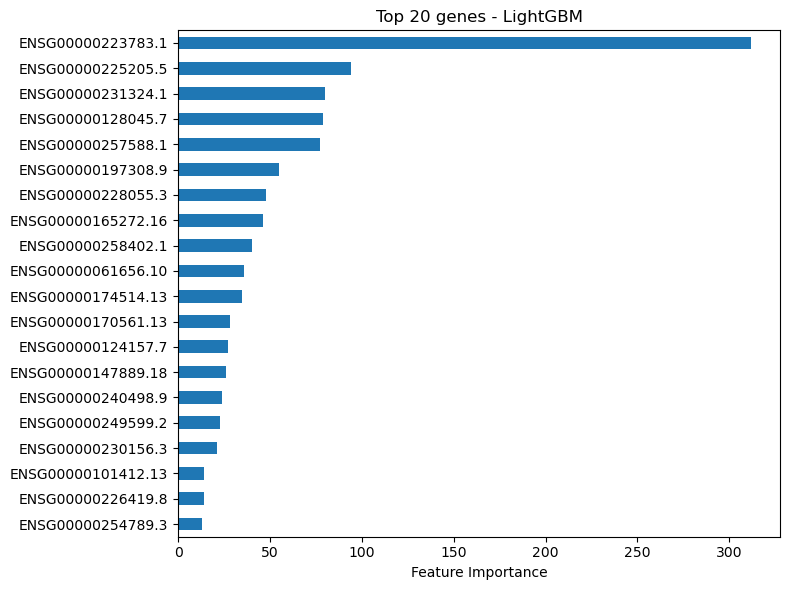

In [113]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(8,6))
top20.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 20 genes - LightGBM")
plt.tight_layout()
plt.show()

In [114]:
from sklearn.metrics import accuracy_score

results = []

for n in [95, 50, 20, 10, 5, 3, 2, 1]:

    genes = importance.head(n).index

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(
        X_train_selected[genes],
        y_train
    )

    pred = model.predict(
        X_test_selected[genes]
    )

    acc = accuracy_score(y_test, pred)

    results.append([n, acc])

[LightGBM] [Info] Number of positive: 50, number of negative: 379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5040
[LightGBM] [Info] Number of data points in the train set: 429, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116550 -> initscore=-2.025513
[LightGBM] [Info] Start training from score -2.025513
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [115]:
results = pd.DataFrame(
    results,
    columns=["Genes", "Accuracy"])

results

,Genes,Accuracy
0,95,0.983696
1,50,0.983696
2,20,0.983696
3,10,0.983696
4,5,0.983696
5,3,0.983696
6,2,0.983696
7,1,0.978261


In [116]:
top2 = importance.head(2).index

lgbm2 = LGBMClassifier(
    n_estimators=300,
g_rate=0.05,
    random_state=42
)

lgbm2.fit(
    X_train_selected[top2],
    y_train
)

[LightGBM] [Warning] Unknown parameter: g_rate
[LightGBM] [Warning] Unknown parameter: g_rate
[LightGBM] [Info] Number of positive: 50, number of negative: 379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 140
[LightGBM] [Info] Number of data points in the train set: 429, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116550 -> initscore=-2.025513
[LightGBM] [Info] Start training from score -2.025513
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [117]:
explainer = shap.TreeExplainer(lgbm2)
shap_values = explainer.shap_values(X_test_selected[top2])

/Users/mateopalmieri/miniconda3/envs/pec2/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


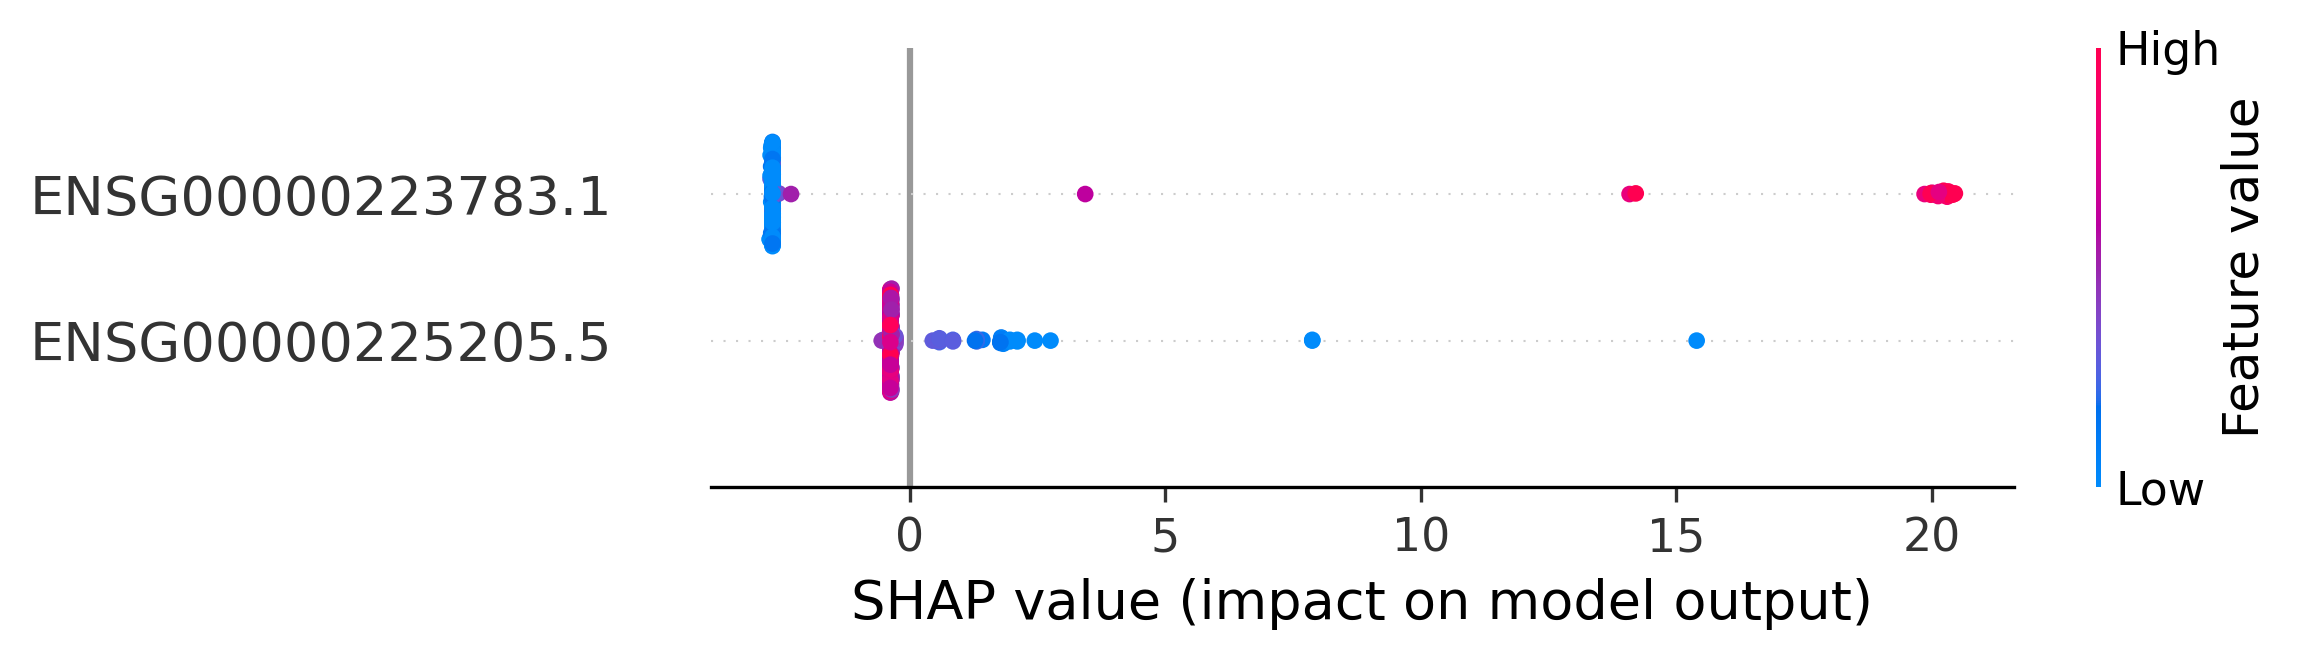

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4), dpi=300)

shap.summary_plot(
    shap_values,
    X_test_selected[top2],
    show=False
)

plt.tight_layout()
plt.show()

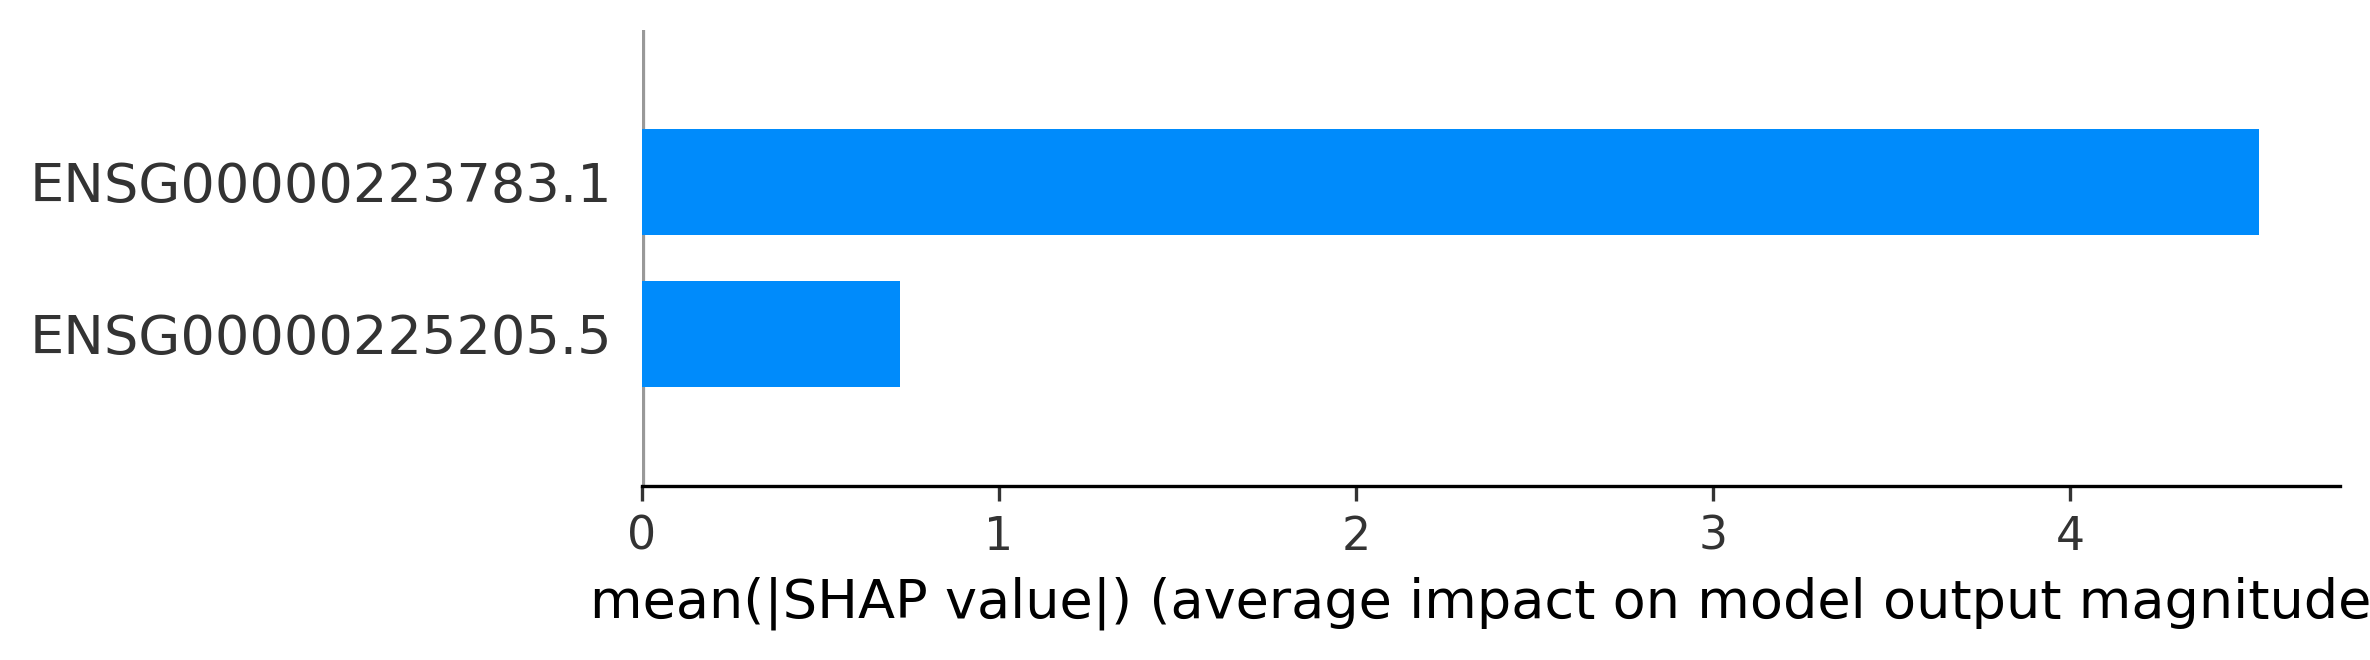

<Figure size 640x480 with 0 Axes>

In [147]:
plt.figure(figsize=(8, 4), dpi=300)

shap.summary_plot(
    shap_values,
    X_test_selected[top2],
    plot_type="bar"
)
plt.tight_layout()
plt.show()

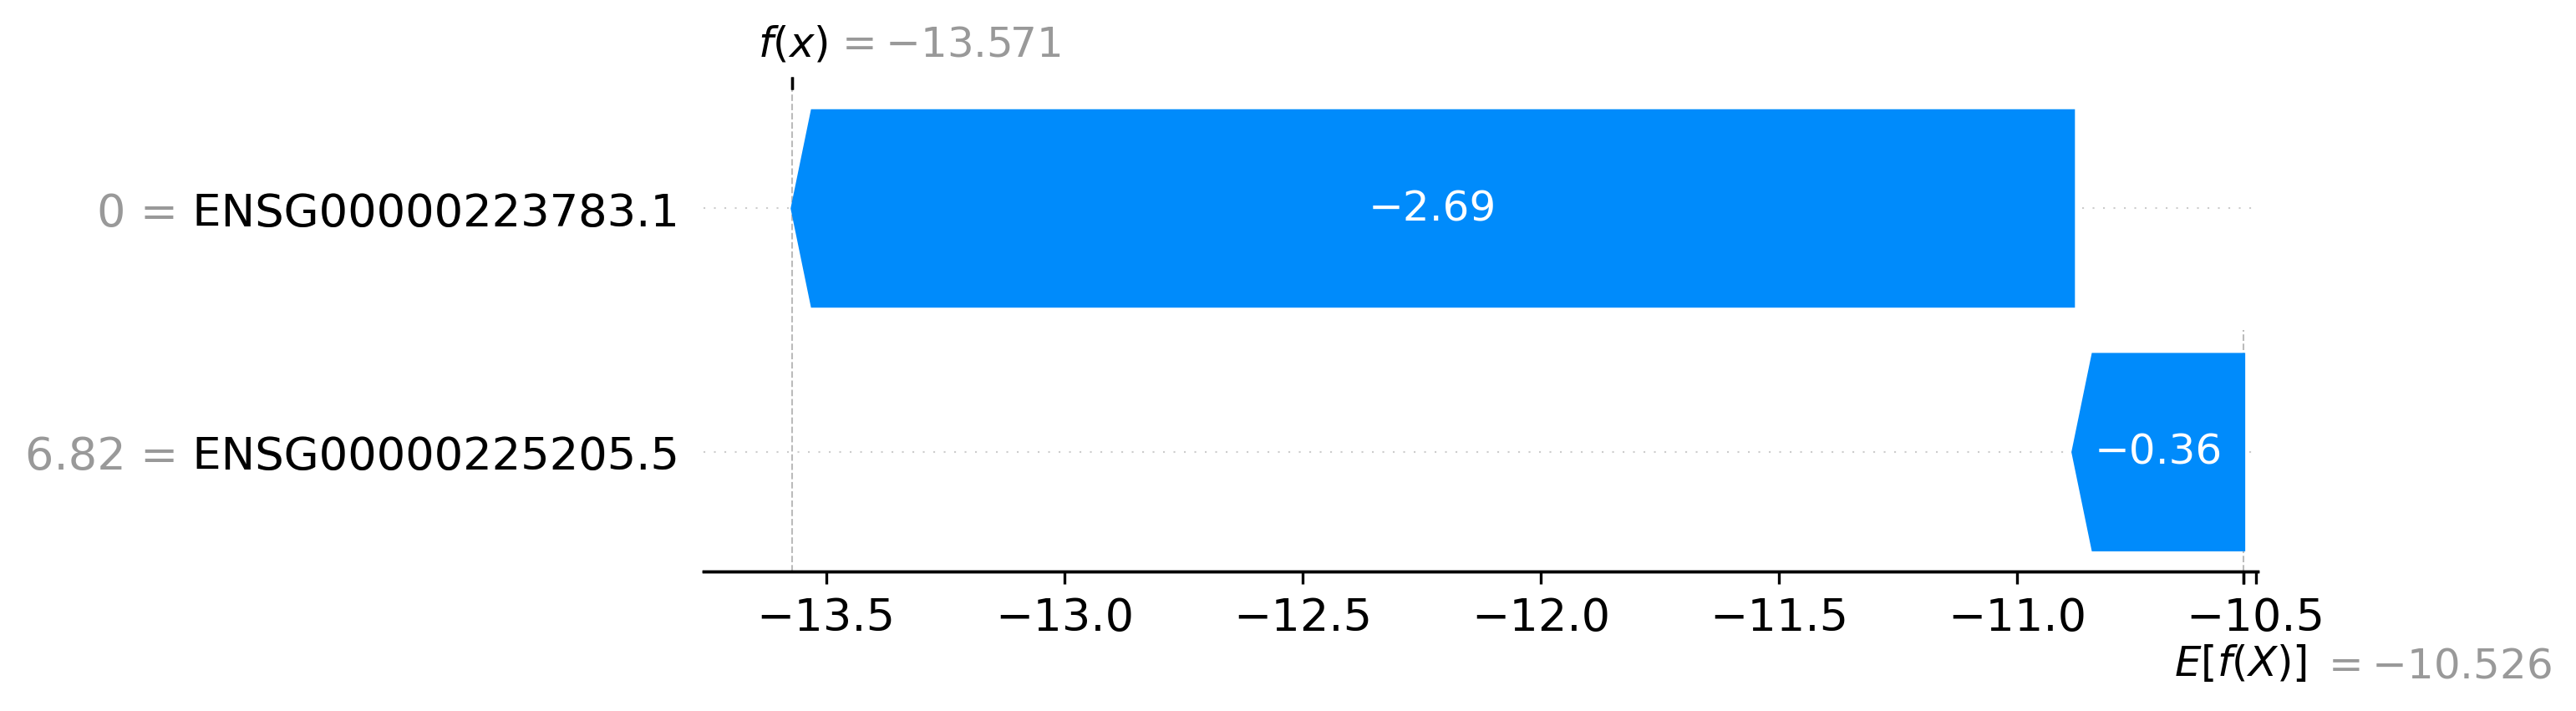

<Figure size 640x480 with 0 Axes>

In [148]:
plt.figure(figsize=(8, 4), dpi=300)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_selected[top2].iloc[0],
        feature_names=top2
    )
)
plt.tight_layout()
plt.show()

In [143]:
genes2 = pd.read_csv("TCGA_KIRC_gene_annotation.csv")

In [144]:
genes2.loc[genes2["gene_id"] == "ENSG00000223783.1", ["gene_name","gene_type"]]

,gene_name,gene_type
24908,LINC01983,lncRNA


In [145]:
genes2.loc[genes2["gene_id"] == "ENSG00000223783.1", ["gene_name","gene_type"]]

,gene_name,gene_type
24908,LINC01983,lncRNA


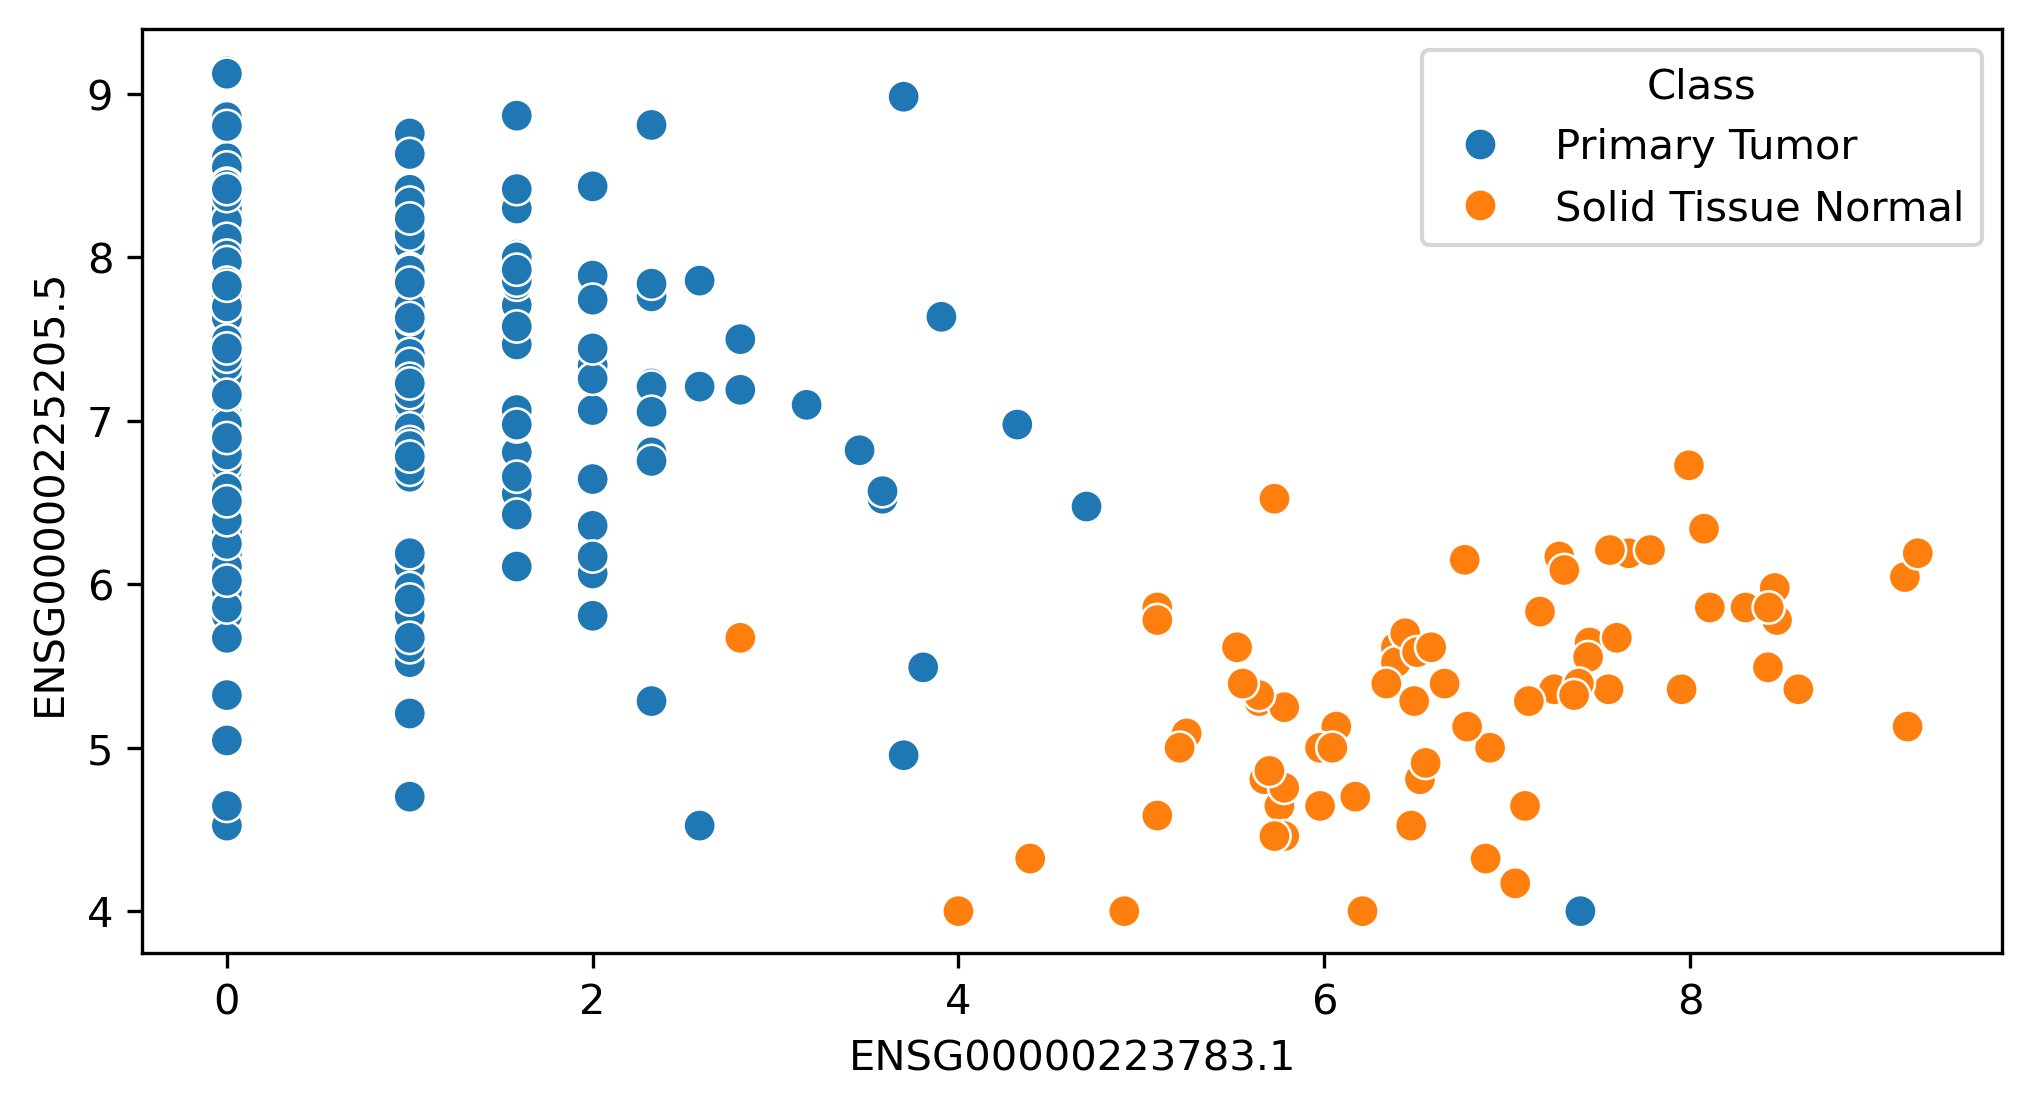

In [149]:
plt.figure(figsize=(8, 4), dpi=300)
plot_df = X_log[top2].copy()
plot_df["Class"] = y_fixed

sns.scatterplot(
    data=plot_df,
    x=top2[0],
    y=top2[1],
    hue="Class",
    s=60
)

plt.show()